# DDoS Model Comparison with Hyperparameter Tuning

Kulon notebook a tuningos benchmarkhoz.

Folyamat:
- SetA split: train/validation/test
- Hyperparameter tuning minden modellre SetA validation alapon
- Vegso kierteseles ugyanazzal a protokollal: SetA test es SetB external
- Ketto scenarioban: regular_class_weight es smote_no_class_weight

In [1]:
from __future__ import annotations

from pathlib import Path
import json
import re
import time
import warnings
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)

print("Imports loaded.")

Imports loaded.


In [2]:
# Experiment config
DATA_DIR = Path("ddos-data-2024")
OUT_DIR = Path("ddos-detection/model_comparison_tuned")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SETA_NAME = "SCLDDoS2024_SetA"
SETB_NAME = "SCLDDoS2024_SetB"
TARGET_COL = "type"

TEST_SIZE = 0.20
VAL_SIZE = 0.10

MODEL_NAMES = ["logistic_regression", "random_forest", "boosting"]
SCENARIOS = ["regular_class_weight", "smote_no_class_weight"]
TUNING_PRIMARY_METRIC = "f1_macro"

EVENTS_COLS = [
    "Attack ID", "Card", "Victim IP", "Port number", "Attack code", "Detect count",
    "Packet speed", "Data speed", "Avg packet len", "Avg source IP count",
    "Start time", "End time", "Type",
]

COMP_COLS = [
    "Attack ID", "Detect count", "Card", "Victim IP", "Port number", "Attack code",
    "Packet speed", "Data speed", "Avg packet len", "Source IP count", "Time",
]

print("Data dir:", DATA_DIR.resolve())
print("Output dir:", OUT_DIR.resolve())

Data dir: /home/aron/ml/halado_adatelemzesi_modszerek/ddos-data-2024
Output dir: /home/aron/ml/halado_adatelemzesi_modszerek/ddos-detection/model_comparison_tuned


In [3]:
BOOSTING_BACKEND = "histgb"

try:
    from xgboost import XGBClassifier
    BOOSTING_BACKEND = "xgboost"
except Exception:
    try:
        from lightgbm import LGBMClassifier
        BOOSTING_BACKEND = "lightgbm"
    except Exception:
        BOOSTING_BACKEND = "histgb"

print(f"Boosting backend selected: {BOOSTING_BACKEND}")

Boosting backend selected: lightgbm


In [4]:
def _to_snake_case(name: str) -> str:
    name = name.strip().lower()
    name = re.sub(r"[^a-z0-9]+", "_", name)
    return re.sub(r"_+", "_", name).strip("_")


def _safe_mode(series: pd.Series):
    vals = series.mode(dropna=True)
    return vals.iloc[0] if not vals.empty else np.nan


def preprocess_recordings(recordings, data_dir=DATA_DIR, verbose=True):
    events_frames = []
    comp_frames = []

    for recording in recordings:
        events_path = Path(data_dir) / f"{recording}_events.csv"
        comp_path = Path(data_dir) / f"{recording}_components.csv"

        if not events_path.exists() or not comp_path.exists():
            raise FileNotFoundError(f"Missing CSV for recording {recording} in {data_dir}")

        events = pd.read_csv(events_path, usecols=EVENTS_COLS)
        comps = pd.read_csv(comp_path, usecols=COMP_COLS)

        events["recording"] = recording
        comps["recording"] = recording

        events_frames.append(events)
        comp_frames.append(comps)

        if verbose:
            print(f"[load] {recording}: events={len(events)}, components={len(comps)}")

    events = pd.concat(events_frames, ignore_index=True)
    comps = pd.concat(comp_frames, ignore_index=True)

    if verbose:
        print(f"[combined] events={len(events)}, components={len(comps)}")

    events = events.drop_duplicates().copy()
    comps = comps.drop_duplicates().copy()

    events["Start time"] = pd.to_datetime(events["Start time"], errors="coerce")
    events["End time"] = pd.to_datetime(events["End time"], errors="coerce")
    comps["Time"] = pd.to_datetime(comps["Time"], errors="coerce")

    events = events.dropna(subset=["Attack ID", "Type", "Start time", "End time"]).copy()
    comps = comps.dropna(subset=["Attack ID", "Time"]).copy()

    events = events.loc[events["End time"] >= events["Start time"]].copy()

    valid_ids = set(events["Attack ID"].unique())
    comps = comps.loc[comps["Attack ID"].isin(valid_ids)].copy()

    events["event_duration_sec"] = (events["End time"] - events["Start time"]).dt.total_seconds()
    events["day_of_week"] = events["Start time"].dt.dayofweek
    events["hour_of_day"] = events["Start time"].dt.hour
    events["is_weekend"] = (events["day_of_week"] >= 5).astype(int)

    events["packet_data_ratio"] = events["Packet speed"] / (events["Data speed"].replace(0, np.nan))
    events["packet_data_ratio"] = events["packet_data_ratio"].replace([np.inf, -np.inf], np.nan)
    events["attack_intensity"] = events["Packet speed"] * events["Avg source IP count"]

    comp_agg = (
        comps.groupby("Attack ID", as_index=False)
        .agg(
            comp_row_count=("Detect count", "size"),
            comp_detect_count_max=("Detect count", "max"),
            comp_packet_speed_mean=("Packet speed", "mean"),
            comp_packet_speed_max=("Packet speed", "max"),
            comp_packet_speed_std=("Packet speed", "std"),
            comp_avg_packet_len_mean=("Avg packet len", "mean"),
            comp_source_ip_count_mean=("Source IP count", "mean"),
            comp_source_ip_count_max=("Source IP count", "max"),
            comp_attack_code_mode=("Attack code", _safe_mode),
            comp_card_mode=("Card", _safe_mode),
            comp_first_time=("Time", "min"),
            comp_last_time=("Time", "max"),
        )
        .copy()
    )

    comp_agg["comp_packet_speed_std"] = comp_agg["comp_packet_speed_std"].fillna(0)
    comp_agg["comp_duration_sec"] = (comp_agg["comp_last_time"] - comp_agg["comp_first_time"]).dt.total_seconds()
    comp_agg["source_ip_growth_rate"] = np.where(
        comp_agg["comp_duration_sec"] > 0,
        comp_agg["comp_source_ip_count_max"] / comp_agg["comp_duration_sec"],
        0.0,
    )

    events = events.sort_values("Start time").drop_duplicates(subset=["Attack ID"], keep="last").copy()
    merged = events.merge(comp_agg, on="Attack ID", how="left")

    merged = merged.drop(columns=["Victim IP", "Data speed"], errors="ignore")
    merged.columns = [_to_snake_case(c) for c in merged.columns]

    num_cols = merged.select_dtypes(include=["number"]).columns
    obj_cols = merged.select_dtypes(exclude=["number"]).columns
    merged[num_cols] = merged[num_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
    merged[obj_cols] = merged[obj_cols].fillna("missing")

    if verbose:
        print(f"[preprocess] rows={len(merged)}, cols={merged.shape[1]}")

    return merged

In [5]:
seta_all = preprocess_recordings([SETA_NAME], data_dir=DATA_DIR, verbose=True)
setb_all = preprocess_recordings([SETB_NAME], data_dir=DATA_DIR, verbose=True)

def _safe_stratify(y: pd.Series):
    if y.nunique() <= 1:
        return None
    if y.value_counts().min() < 2:
        return None
    return y

strat = _safe_stratify(seta_all[TARGET_COL])
seta_train_val, seta_test = train_test_split(
    seta_all,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=strat,
)

val_ratio_in_train_val = VAL_SIZE / (1.0 - TEST_SIZE)
strat_tv = _safe_stratify(seta_train_val[TARGET_COL])
seta_train, seta_val = train_test_split(
    seta_train_val,
    test_size=val_ratio_in_train_val,
    random_state=RANDOM_STATE,
    stratify=strat_tv,
)

print("SetA splits:")
print("- train:", seta_train.shape)
print("- val:", seta_val.shape)
print("- test:", seta_test.shape)
print("SetB all:", setb_all.shape)

print("\nSetA train class distribution:")
display(seta_train[TARGET_COL].value_counts())

print("SetA validation class distribution:")
display(seta_val[TARGET_COL].value_counts())

print("SetA test class distribution:")
display(seta_test[TARGET_COL].value_counts())

print("SetB class distribution:")
display(setb_all[TARGET_COL].value_counts())

[load] SCLDDoS2024_SetA: events=134770, components=586642
[combined] events=134770, components=586642
[preprocess] rows=134766, cols=32
[load] SCLDDoS2024_SetB: events=130000, components=1233449
[combined] events=130000, components=1233449
[preprocess] rows=130000, cols=32
SetA splits:
- train: (94335, 32)
- val: (13477, 32)
- test: (26954, 32)
SetB all: (130000, 32)

SetA train class distribution:


type
Normal traffic        86892
Suspicious traffic     6794
DDoS attack             649
Name: count, dtype: int64

SetA validation class distribution:


type
Normal traffic        12414
Suspicious traffic      971
DDoS attack              92
Name: count, dtype: int64

SetA test class distribution:


type
Normal traffic        24827
Suspicious traffic     1942
DDoS attack             185
Name: count, dtype: int64

SetB class distribution:


type
Normal traffic        124880
Suspicious traffic      3673
DDoS attack             1447
Name: count, dtype: int64

In [6]:
LEAKAGE_DROP_COLS = [
    TARGET_COL,
    "attack_id",
    "recording",
    "start_time",
    "end_time",
    "comp_first_time",
    "comp_last_time",
    "attack_code",
    "comp_attack_code_mode",
]

def split_xy(df: pd.DataFrame, target_col: str = TARGET_COL):
    usable_drop = [c for c in LEAKAGE_DROP_COLS if c in df.columns]
    X = df.drop(columns=usable_drop).copy()
    y = df[target_col].copy()
    return X, y

def build_preprocessor(X_fit: pd.DataFrame):
    cat_cols = X_fit.select_dtypes(include=["object", "string", "category", "bool"]).columns.tolist()
    num_cols = X_fit.select_dtypes(include=["number"]).columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]),
                num_cols,
            ),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]),
                cat_cols,
            ),
        ],
        remainder="drop",
    )
    return preprocessor

def to_dense(X):
    return X.toarray() if hasattr(X, "toarray") else np.asarray(X)


X_train_raw, y_train = split_xy(seta_train)
X_val_raw, y_val = split_xy(seta_val)
X_test_raw, y_test = split_xy(seta_test)
X_setb_raw, y_setb = split_xy(setb_all)

# Tuning encoding: fit only on SetA train
preprocessor_tune = build_preprocessor(X_train_raw)
X_train_tune = to_dense(preprocessor_tune.fit_transform(X_train_raw)).astype(np.float32)
X_val_tune = to_dense(preprocessor_tune.transform(X_val_raw)).astype(np.float32)

print("Tuning feature count:", len(preprocessor_tune.get_feature_names_out()))

Tuning feature count: 23


In [7]:
def compute_multiclass_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
    }


def balanced_sample_weights(y: pd.Series) -> np.ndarray:
    classes = np.unique(y)
    class_w = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    class_map = dict(zip(classes, class_w))
    return y.map(class_map).values.astype(np.float32)


def apply_smote_train_only(X_train_enc, y_train_series: pd.Series):
    class_counts = y_train_series.value_counts()
    min_count = int(class_counts.min())
    if min_count < 2:
        raise ValueError("SMOTE requires at least 2 samples in the smallest class.")

    k_neighbors = min(5, min_count - 1)
    smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=k_neighbors)
    X_res, y_res = smote.fit_resample(X_train_enc, y_train_series)
    return X_res, y_res


def expand_param_grid(grid_dict):
    keys = list(grid_dict.keys())
    values = [grid_dict[k] for k in keys]
    combos = []
    for vals in product(*values):
        combos.append(dict(zip(keys, vals)))
    return combos


def get_param_grid(model_name: str, backend: str):
    if model_name == "logistic_regression":
        return expand_param_grid({
            "C": [0.2, 1.0, 4.0],
            "max_iter": [2500],
        })

    if model_name == "random_forest":
        return expand_param_grid({
            "n_estimators": [250, 400],
            "max_depth": [14, 22],
            "min_samples_leaf": [1, 2],
        })

    if model_name == "boosting":
        if backend == "xgboost":
            return expand_param_grid({
                "n_estimators": [250, 400],
                "max_depth": [6, 8],
                "learning_rate": [0.05, 0.1],
            })

        if backend == "lightgbm":
            return expand_param_grid({
                "n_estimators": [250, 400],
                "learning_rate": [0.05, 0.1],
                "num_leaves": [31, 63],
            })

        return expand_param_grid({
            "max_iter": [250, 400],
            "max_depth": [8, 12],
            "learning_rate": [0.05, 0.1],
        })

    raise ValueError(f"Unknown model_name: {model_name}")


def make_model(model_name: str, use_class_weight: bool, params: dict):
    if model_name == "logistic_regression":
        return LogisticRegression(
            solver="lbfgs",
            class_weight=("balanced" if use_class_weight else None),
            random_state=RANDOM_STATE,
            **params,
        )

    if model_name == "random_forest":
        return RandomForestClassifier(
            class_weight=("balanced_subsample" if use_class_weight else None),
            random_state=RANDOM_STATE,
            n_jobs=-1,
            **params,
        )

    if model_name == "boosting":
        if BOOSTING_BACKEND == "xgboost":
            return XGBClassifier(
                objective="multi:softprob",
                eval_metric="mlogloss",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                **params,
            )

        if BOOSTING_BACKEND == "lightgbm":
            return LGBMClassifier(
                objective="multiclass",
                class_weight=("balanced" if use_class_weight else None),
                random_state=RANDOM_STATE,
                **params,
            )

        return HistGradientBoostingClassifier(
            random_state=RANDOM_STATE,
            **params,
        )

    raise ValueError(f"Unknown model_name: {model_name}")

In [8]:
def tune_model_on_validation(model_name: str, scenario: str):
    if scenario not in SCENARIOS:
        raise ValueError(f"Unknown scenario: {scenario}")

    use_class_weight = scenario == "regular_class_weight"
    param_grid = get_param_grid(model_name, BOOSTING_BACKEND)

    if scenario == "smote_no_class_weight":
        X_fit, y_fit = apply_smote_train_only(X_train_tune, y_train)
    else:
        X_fit, y_fit = X_train_tune, y_train

    tuning_rows = []
    for idx, params in enumerate(param_grid, start=1):
        model = make_model(model_name, use_class_weight=use_class_weight, params=params)

        fit_kwargs = {}
        if use_class_weight and model_name == "boosting" and BOOSTING_BACKEND in {"xgboost", "histgb"}:
            fit_kwargs["sample_weight"] = balanced_sample_weights(y_fit)

        t0 = time.perf_counter()
        model.fit(X_fit, y_fit, **fit_kwargs)
        fit_time = time.perf_counter() - t0

        pred_val = model.predict(X_val_tune)
        val_metrics = compute_multiclass_metrics(y_val, pred_val)

        tuning_rows.append({
            "model": model_name,
            "scenario": scenario,
            "candidate_idx": idx,
            "params": json.dumps(params, sort_keys=True),
            **val_metrics,
            "fit_time_sec": fit_time,
        })

    tuning_df_local = pd.DataFrame(tuning_rows)
    tuning_df_local = tuning_df_local.sort_values(["f1_macro", "balanced_accuracy", "accuracy"], ascending=[False, False, False]).reset_index(drop=True)

    best_row = tuning_df_local.iloc[0].copy()
    best_params = json.loads(best_row["params"])
    return best_params, tuning_df_local


all_tuning_rows = []
best_params_map = {}

for model_name in MODEL_NAMES:
    for scenario in SCENARIOS:
        print(f"Tuning {model_name} / {scenario}")
        best_params, tuning_table = tune_model_on_validation(model_name, scenario)
        best_params_map[(model_name, scenario)] = best_params
        all_tuning_rows.append(tuning_table)

tuning_results_df = pd.concat(all_tuning_rows, ignore_index=True)
display(tuning_results_df.head(20))

print("Best params per model/scenario:")
for key, params in best_params_map.items():
    print(f"- {key}: {params}")

Tuning logistic_regression / regular_class_weight
Tuning logistic_regression / smote_no_class_weight
Tuning random_forest / regular_class_weight
Tuning random_forest / smote_no_class_weight
Tuning boosting / regular_class_weight
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000613 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4593
[LightGBM] [Info] Number of data points in the train set: 94335, number of used features: 21
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000549 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4

,model,scenario,candidate_idx,params,accuracy,balanced_accuracy,f1_macro,fit_time_sec
0,logistic_regression,regular_class_weight,3,"{""C"": 4.0, ""max_iter"": 2500}",0.650664,0.720071,0.394096,2.908671
1,logistic_regression,regular_class_weight,2,"{""C"": 1.0, ""max_iter"": 2500}",0.648883,0.718478,0.392756,2.156852
2,logistic_regression,regular_class_weight,1,"{""C"": 0.2, ""max_iter"": 2500}",0.648586,0.718370,0.392532,1.503841
3,logistic_regression,smote_no_class_weight,2,"{""C"": 1.0, ""max_iter"": 2500}",0.645841,0.726669,0.392499,9.069376
4,logistic_regression,smote_no_class_weight,3,"{""C"": 4.0, ""max_iter"": 2500}",0.645173,0.723780,0.391906,11.189772
5,logistic_regression,smote_no_class_weight,1,"{""C"": 0.2, ""max_iter"": 2500}",0.645099,0.725451,0.391755,4.876265
6,random_forest,regular_class_weight,4,"{""max_depth"": 22, ""min_samples_leaf"": 2, ""n_es...",0.951547,0.881427,0.847253,1.860073
7,random_forest,regular_class_weight,8,"{""max_depth"": 22, ""min_samples_leaf"": 2, ""n_es...",0.952066,0.881299,0.846508,2.971702
8,random_forest,regular_class_weight,3,"{""max_depth"": 22, ""min_samples_leaf"": 1, ""n_es...",0.952289,0.860981,0.846089,1.907681
9,random_forest,regular_class_weight,7,"{""max_depth"": 22, ""min_samples_leaf"": 1, ""n_es...",0.952141,0.852786,0.840928,2.956816


Best params per model/scenario:
- ('logistic_regression', 'regular_class_weight'): {'C': 4.0, 'max_iter': 2500}
- ('logistic_regression', 'smote_no_class_weight'): {'C': 1.0, 'max_iter': 2500}
- ('random_forest', 'regular_class_weight'): {'max_depth': 22, 'min_samples_leaf': 2, 'n_estimators': 250}
- ('random_forest', 'smote_no_class_weight'): {'max_depth': 22, 'min_samples_leaf': 1, 'n_estimators': 250}
- ('boosting', 'regular_class_weight'): {'learning_rate': 0.1, 'n_estimators': 400, 'num_leaves': 63}
- ('boosting', 'smote_no_class_weight'): {'learning_rate': 0.05, 'n_estimators': 400, 'num_leaves': 63}


In [9]:
# Final comparison protocol with tuned hyperparameters
X_train_val_raw = pd.concat([X_train_raw, X_val_raw], ignore_index=True)
y_train_val = pd.concat([y_train.reset_index(drop=True), y_val.reset_index(drop=True)], ignore_index=True)

preprocessor_final = build_preprocessor(X_train_val_raw)
X_train_val_enc = to_dense(preprocessor_final.fit_transform(X_train_val_raw)).astype(np.float32)
X_test_enc = to_dense(preprocessor_final.transform(X_test_raw)).astype(np.float32)
X_setb_enc = to_dense(preprocessor_final.transform(X_setb_raw)).astype(np.float32)

final_rows = []
final_predictions = {}
final_models = {}

for model_name in MODEL_NAMES:
    for scenario in SCENARIOS:
        params = best_params_map[(model_name, scenario)]
        use_class_weight = scenario == "regular_class_weight"

        if scenario == "smote_no_class_weight":
            X_fit, y_fit = apply_smote_train_only(X_train_val_enc, y_train_val)
        else:
            X_fit, y_fit = X_train_val_enc, y_train_val

        model = make_model(model_name, use_class_weight=use_class_weight, params=params)
        fit_kwargs = {}
        if use_class_weight and model_name == "boosting" and BOOSTING_BACKEND in {"xgboost", "histgb"}:
            fit_kwargs["sample_weight"] = balanced_sample_weights(y_fit)

        t0 = time.perf_counter()
        model.fit(X_fit, y_fit, **fit_kwargs)
        fit_time = time.perf_counter() - t0

        t1 = time.perf_counter()
        pred_test = model.predict(X_test_enc)
        pred_setb = model.predict(X_setb_enc)
        predict_time = time.perf_counter() - t1

        met_test = compute_multiclass_metrics(y_test, pred_test)
        met_setb = compute_multiclass_metrics(y_setb, pred_setb)

        final_rows.append({
            "model": model_name,
            "scenario": scenario,
            "dataset": "seta_test",
            **met_test,
            "fit_time_sec": fit_time,
            "predict_time_sec": predict_time,
            "best_params": json.dumps(params, sort_keys=True),
        })
        final_rows.append({
            "model": model_name,
            "scenario": scenario,
            "dataset": "setb_external",
            **met_setb,
            "fit_time_sec": fit_time,
            "predict_time_sec": predict_time,
            "best_params": json.dumps(params, sort_keys=True),
        })

        final_models[(model_name, scenario)] = model
        final_predictions[(model_name, scenario)] = {
            "seta_test": pred_test,
            "setb_external": pred_setb,
        }

final_results_df = pd.DataFrame(final_rows)
final_results_df = final_results_df.sort_values(["dataset", "f1_macro", "balanced_accuracy", "accuracy"], ascending=[True, False, False, False]).reset_index(drop=True)

print("Tuned final comparison:")
display(final_results_df)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000643 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4591
[LightGBM] [Info] Number of data points in the train set: 107812, number of used features: 21
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001344 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5353
[LightGBM] [Info] Number of data points in the train set: 297918, number of used features: 21
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Star

,model,scenario,dataset,accuracy,balanced_accuracy,f1_macro,fit_time_sec,predict_time_sec,best_params
0,boosting,smote_no_class_weight,seta_test,0.962863,0.875773,0.857489,4.499557,0.689037,"{""learning_rate"": 0.05, ""n_estimators"": 400, ""..."
1,boosting,regular_class_weight,seta_test,0.962195,0.875670,0.854929,2.286221,0.716822,"{""learning_rate"": 0.1, ""n_estimators"": 400, ""n..."
2,random_forest,regular_class_weight,seta_test,0.953291,0.870453,0.840533,2.257246,0.195913,"{""max_depth"": 22, ""min_samples_leaf"": 2, ""n_es..."
3,random_forest,smote_no_class_weight,seta_test,0.949989,0.891999,0.823438,8.375816,0.217302,"{""max_depth"": 22, ""min_samples_leaf"": 1, ""n_es..."
4,logistic_regression,regular_class_weight,seta_test,0.652259,0.693627,0.390967,6.300537,0.011148,"{""C"": 4.0, ""max_iter"": 2500}"
5,logistic_regression,smote_no_class_weight,seta_test,0.649069,0.702267,0.390964,13.061924,0.014379,"{""C"": 1.0, ""max_iter"": 2500}"
6,random_forest,regular_class_weight,setb_external,0.941562,0.467125,0.513300,2.257246,0.195913,"{""max_depth"": 22, ""min_samples_leaf"": 2, ""n_es..."
7,boosting,regular_class_weight,setb_external,0.937215,0.472048,0.498694,2.286221,0.716822,"{""learning_rate"": 0.1, ""n_estimators"": 400, ""n..."
8,boosting,smote_no_class_weight,setb_external,0.941031,0.488327,0.493470,4.499557,0.689037,"{""learning_rate"": 0.05, ""n_estimators"": 400, ""..."
9,random_forest,smote_no_class_weight,setb_external,0.928362,0.473656,0.451605,8.375816,0.217302,"{""max_depth"": 22, ""min_samples_leaf"": 1, ""n_es..."


accuracy               balanced_accuracy                f1_macro              
dataset                                   seta_test setb_external         seta_test setb_external seta_test setb_external
model               scenario                                                                                             
boosting            regular_class_weight   0.962195      0.937215          0.875670      0.472048  0.854929      0.498694
                    smote_no_class_weight  0.962863      0.941031          0.875773      0.488327  0.857489      0.493470
logistic_regression regular_class_weight   0.652259      0.618700          0.693627      0.340646  0.390967      0.278231
                    smote_no_class_weight  0.649069      0.592977          0.702267      0.335223  0.390964      0.269297
random_forest       regular_class_weight   0.953291      0.941562          0.870453      0.467125  0.840533      0.513300
                    smote_no_class_weight  0.949989      0.928362          0.891999      0.473656  0.823438      0.451605

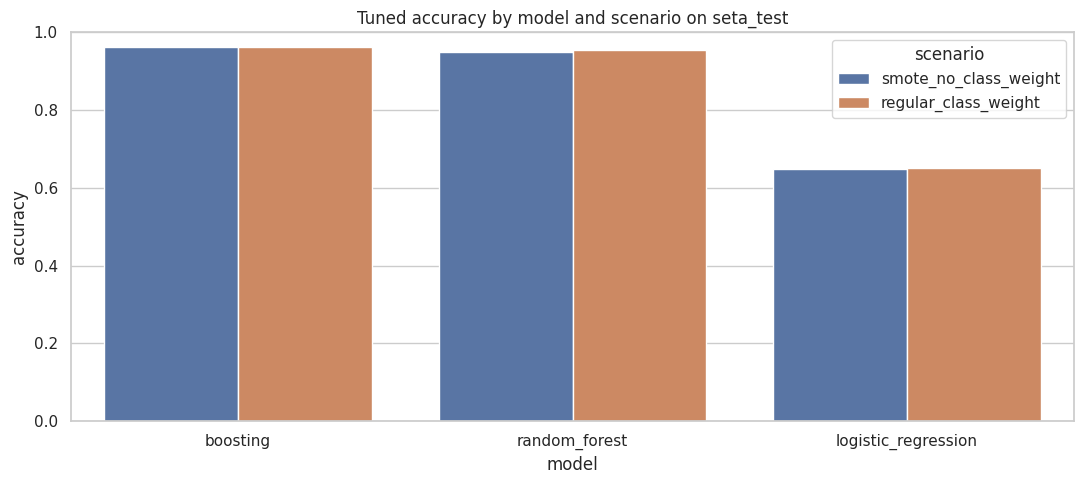

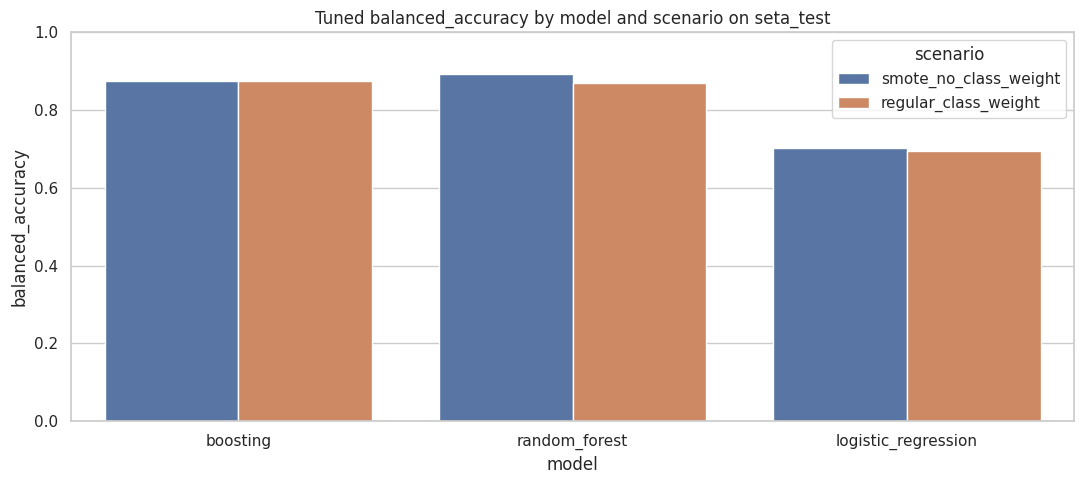

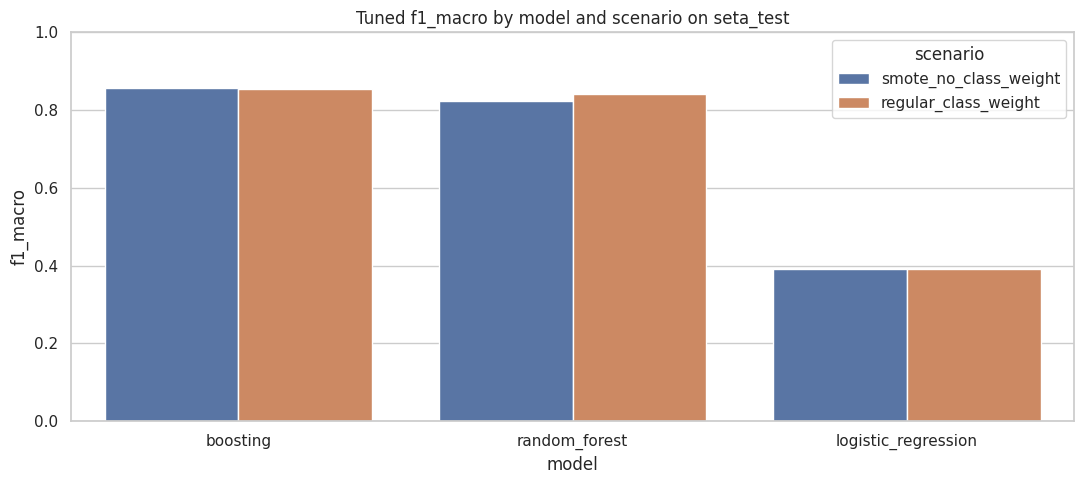

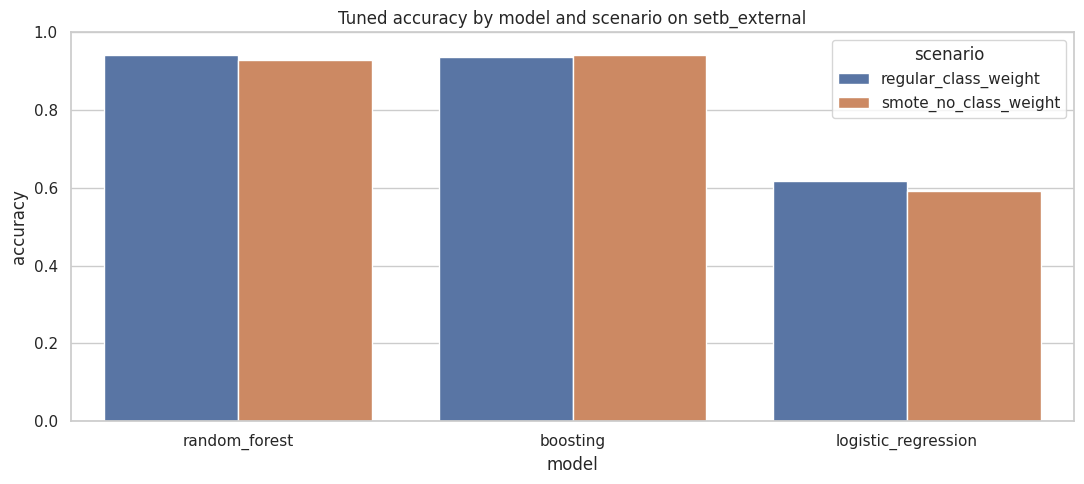

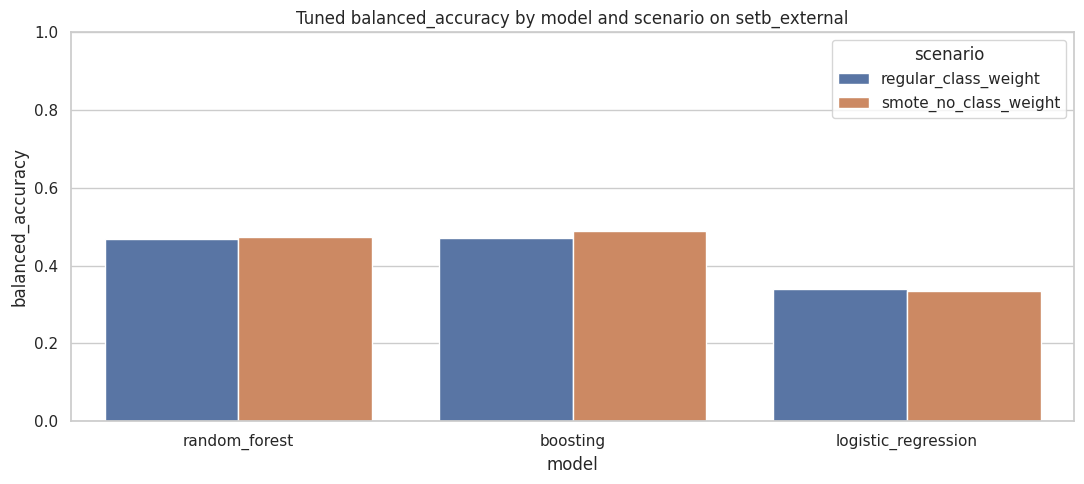

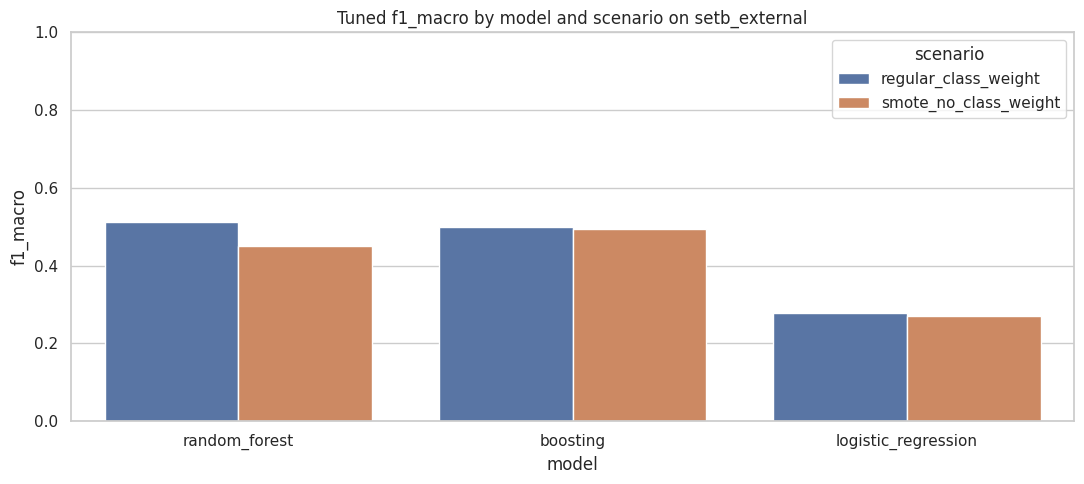

SMOTE delta after tuning (smote - regular):


,model,dataset,delta_accuracy,delta_balanced_accuracy,delta_f1_macro
0,logistic_regression,seta_test,-0.003191,0.008641,-0.000004
1,logistic_regression,setb_external,-0.025723,-0.005422,-0.008934
2,random_forest,seta_test,-0.003302,0.021546,-0.017095
3,random_forest,setb_external,-0.013200,0.006532,-0.061695
4,boosting,seta_test,0.000668,0.000103,0.002561
5,boosting,setb_external,0.003815,0.016279,-0.005223


In [10]:
summary_pivot = final_results_df.pivot_table(
    index=["model", "scenario"],
    columns="dataset",
    values=["accuracy", "balanced_accuracy", "f1_macro"],
    aggfunc="mean",
)
display(summary_pivot)

for ds in ["seta_test", "setb_external"]:
    subset = final_results_df[final_results_df["dataset"] == ds].copy()
    for metric in ["accuracy", "balanced_accuracy", "f1_macro"]:
        plt.figure(figsize=(11, 5))
        ax = sns.barplot(
            data=subset,
            x="model",
            y=metric,
            hue="scenario",
            errorbar=None,
        )
        ax.set_ylim(0, 1)
        ax.set_title(f"Tuned {metric} by model and scenario on {ds}")
        plt.tight_layout()
        plt.show()

delta_rows = []
for model_name in MODEL_NAMES:
    for ds in ["seta_test", "setb_external"]:
        reg = final_results_df[(final_results_df["model"] == model_name) & (final_results_df["scenario"] == "regular_class_weight") & (final_results_df["dataset"] == ds)]
        smo = final_results_df[(final_results_df["model"] == model_name) & (final_results_df["scenario"] == "smote_no_class_weight") & (final_results_df["dataset"] == ds)]
        if len(reg) == 1 and len(smo) == 1:
            delta_rows.append({
                "model": model_name,
                "dataset": ds,
                "delta_accuracy": float(smo.iloc[0]["accuracy"] - reg.iloc[0]["accuracy"]),
                "delta_balanced_accuracy": float(smo.iloc[0]["balanced_accuracy"] - reg.iloc[0]["balanced_accuracy"]),
                "delta_f1_macro": float(smo.iloc[0]["f1_macro"] - reg.iloc[0]["f1_macro"]),
            })

delta_df = pd.DataFrame(delta_rows)
print("SMOTE delta after tuning (smote - regular):")
display(delta_df)

Best tuned run on SetA test:


,model,scenario,dataset,accuracy,balanced_accuracy,f1_macro,fit_time_sec,predict_time_sec,best_params
0,boosting,smote_no_class_weight,seta_test,0.962863,0.875773,0.857489,4.499557,0.689037,"{""learning_rate"": 0.05, ""n_estimators"": 400, ""..."


Best tuned run on SetB external:


,model,scenario,dataset,accuracy,balanced_accuracy,f1_macro,fit_time_sec,predict_time_sec,best_params
6,random_forest,regular_class_weight,setb_external,0.941562,0.467125,0.5133,2.257246,0.195913,"{""max_depth"": 22, ""min_samples_leaf"": 2, ""n_es..."


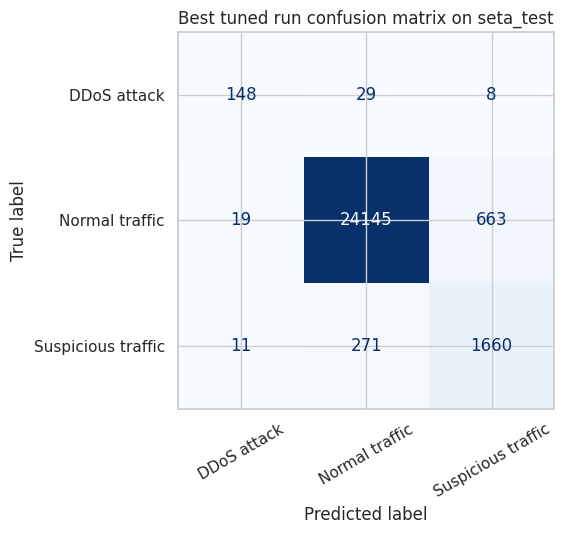

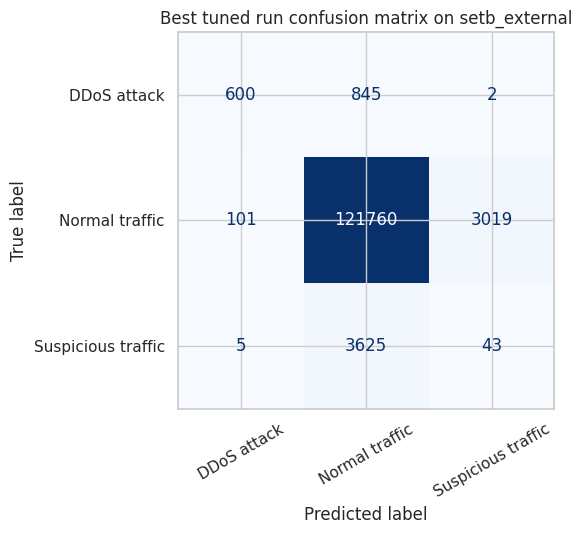

In [11]:
def best_run_for_dataset(results: pd.DataFrame, dataset_name: str):
    sub = results[results["dataset"] == dataset_name].copy()
    sub = sub.sort_values(["f1_macro", "balanced_accuracy", "accuracy"], ascending=False)
    return sub.iloc[0]

best_seta = best_run_for_dataset(final_results_df, "seta_test")
best_setb = best_run_for_dataset(final_results_df, "setb_external")

print("Best tuned run on SetA test:")
display(best_seta.to_frame().T)
print("Best tuned run on SetB external:")
display(best_setb.to_frame().T)

for ds_name, y_true, best_row in [
    ("seta_test", y_test, best_seta),
    ("setb_external", y_setb, best_setb),
]:
    key = (best_row["model"], best_row["scenario"])
    y_pred = final_predictions[key][ds_name]

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        ax=ax,
        cmap="Blues",
        xticks_rotation=30,
        colorbar=False,
    )
    ax.set_title(f"Best tuned run confusion matrix on {ds_name}")
    plt.tight_layout()
    plt.show()

In [12]:
# Persist artifacts
tuning_path = OUT_DIR / "tuning_candidates_validation.csv"
best_params_path = OUT_DIR / "best_params_by_model_scenario.json"
final_results_path = OUT_DIR / "final_tuned_comparison_results.csv"
delta_path = OUT_DIR / "final_tuned_smote_delta.csv"
summary_path = OUT_DIR / "final_tuned_summary_pivot.csv"
config_path = OUT_DIR / "tuned_experiment_config.json"

tuning_results_df.to_csv(tuning_path, index=False)
final_results_df.to_csv(final_results_path, index=False)
delta_df.to_csv(delta_path, index=False)
summary_pivot.reset_index().to_csv(summary_path, index=False)

best_params_dump = {f"{k[0]}::{k[1]}": v for k, v in best_params_map.items()}
with open(best_params_path, "w", encoding="utf-8") as f:
    json.dump(best_params_dump, f, indent=2)

config_payload = {
    "seta": SETA_NAME,
    "setb": SETB_NAME,
    "target": TARGET_COL,
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "val_size": VAL_SIZE,
    "models": MODEL_NAMES,
    "scenarios": SCENARIOS,
    "tuning_primary_metric": TUNING_PRIMARY_METRIC,
    "boosting_backend": BOOSTING_BACKEND,
}
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config_payload, f, indent=2)

print("Saved artifacts:")
print(f"- {tuning_path}")
print(f"- {best_params_path}")
print(f"- {final_results_path}")
print(f"- {delta_path}")
print(f"- {summary_path}")
print(f"- {config_path}")

Saved artifacts:
- ddos-detection/model_comparison_tuned/tuning_candidates_validation.csv
- ddos-detection/model_comparison_tuned/best_params_by_model_scenario.json
- ddos-detection/model_comparison_tuned/final_tuned_comparison_results.csv
- ddos-detection/model_comparison_tuned/final_tuned_smote_delta.csv
- ddos-detection/model_comparison_tuned/final_tuned_summary_pivot.csv
- ddos-detection/model_comparison_tuned/tuned_experiment_config.json


## Notes

- Tuning csak SetA train -> validation vonalon tortenik.
- Vegso meres a kivalsztott parameterekkel: SetA test es SetB external.
- SMOTE csak train oldalon fut (tuningnal train, vegso futasnal train+val).